In [1]:
# AI Maternal Mortality Risk Predictor
# Step 1: Define the Problem

# We are building a Binary Classification Model

# Target Variable:
# 1 = High-Risk Pregnancy
# 0 = Low-Risk Pregnancy

print("Project: AI Maternal Risk Predictor 💙")
print("Target: Predict High-Risk Pregnancy (1 = Yes, 0 = No)")

Project: AI Maternal Risk Predictor 💙
Target: Predict High-Risk Pregnancy (1 = Yes, 0 = No)


In [2]:
import pandas as pd

df = pd.read_csv("data/maternal.csv")

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully ✅
Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
# Check unique values in RiskLevel
print("Unique Risk Levels:", df["RiskLevel"].unique())

Unique Risk Levels: ['high risk' 'low risk' 'mid risk']


In [4]:
# Convert RiskLevel to binary
# low risk = 0
# mid risk & high risk = 1

df["RiskLevel"] = df["RiskLevel"].replace({
    "low risk": 0,
    "mid risk": 1,
    "high risk": 1
})

print("Converted RiskLevel to Binary ✅")
print(df["RiskLevel"].value_counts())

Converted RiskLevel to Binary ✅
RiskLevel
1    608
0    406
Name: count, dtype: int64


C:\Users\~ Ajay ~\AppData\Local\Temp\ipykernel_39976\1545176381.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["RiskLevel"] = df["RiskLevel"].replace({


In [5]:
# Separate features (X) and target (y)

X = df.drop("RiskLevel", axis=1)  # all columns except RiskLevel
y = df["RiskLevel"]               # only RiskLevel column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (1014, 6)
Target shape: (1014,)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76


In [6]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (811, 6)
Testing set size: (203, 6)


In [7]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully ✅")

Logistic Regression Model Trained Successfully ✅


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]  # probability for class 1

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))   # IMPORTANT
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7142857142857143
Precision: 0.8155339805825242
Recall   : 0.6829268292682927
F1 Score : 0.7433628318584071
ROC-AUC  : 0.8112296747967479

Confusion Matrix:
 [[61 19]
 [39 84]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully ✅")

Random Forest Model Trained Successfully ✅


In [10]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8571428571428571
Precision: 0.8455882352941176
Recall   : 0.9349593495934959
F1 Score : 0.888030888030888
ROC-AUC  : 0.9338922764227642

Confusion Matrix:
 [[ 59  21]
 [  8 115]]


       Feature  Importance
3           BS    0.368044
0          Age    0.174994
1   SystolicBP    0.157289
2  DiastolicBP    0.108191
5    HeartRate    0.101145
4     BodyTemp    0.090337


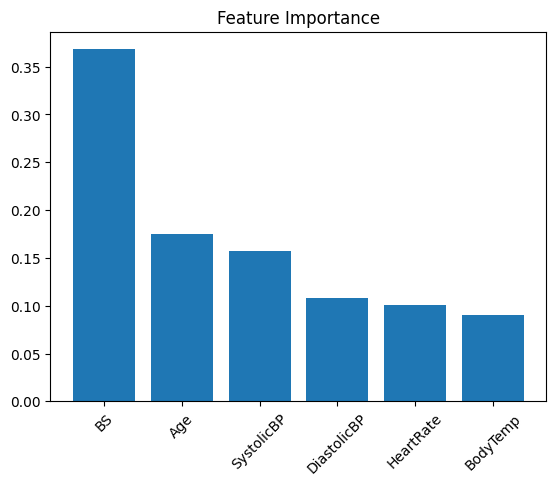

In [11]:
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_
features = X.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Plot
plt.figure()
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [12]:
import joblib

# Save trained Random Forest model
joblib.dump(rf_model, "maternal_risk_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [13]:
# Function to predict risk score and category

def predict_risk(input_data):
    # Convert input into dataframe
    input_df = pd.DataFrame([input_data], columns=X.columns)
    
    # Get probability of high risk
    prob = rf_model.predict_proba(input_df)[0][1]
    
    # Convert to percentage
    risk_score = prob * 100
    
    # Assign category
    if risk_score < 30:
        category = "Low Risk"
        recommendation = "Routine monitoring"
    elif risk_score < 70:
        category = "Moderate Risk"
        recommendation = "Schedule follow-up tests"
    else:
        category = "High Risk"
        recommendation = "Immediate referral to hospital"
    
    return risk_score, category, recommendation

In [14]:
# Example patient (you can modify values)

sample_patient = {
    "Age": 35,
    "SystolicBP": 150,
    "DiastolicBP": 95,
    "BS": 14.0,
    "BodyTemp": 99.0,
    "HeartRate": 90
}

score, category, recommendation = predict_risk(sample_patient)

print("Risk Score:", round(score, 2), "%")
print("Risk Category:", category)
print("Recommendation:", recommendation)

Risk Score: 100.0 %
Risk Category: High Risk
Recommendation: Immediate referral to hospital


In [15]:
import shap
import pandas as pd

# SHAP explainer (TreeExplainer works great for RandomForest)
explainer = shap.TreeExplainer(rf_model)

# Pick one test sample (or any row)
idx = 0
x_one = X_test.iloc[[idx]]  # keep as DataFrame

shap_values = explainer.shap_values(x_one)

print("Predicted prob (high risk):", rf_model.predict_proba(x_one)[0][1])
display(x_one)

c:\Users\~ Ajay ~\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Predicted prob (high risk): 1.0


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
752,29,130,70,7.7,98.0,78


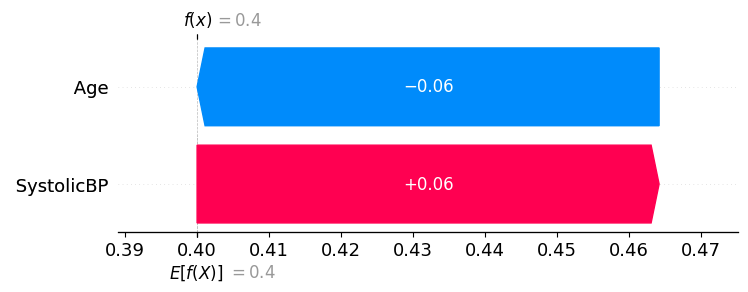

In [18]:
import numpy as np
import shap

# Recompute to be safe
shap_values = explainer.shap_values(x_one)

# Handle both SHAP formats:
# 1) list (one array per class)  -> use class 1
# 2) single array (already for class 1 / model output)
if isinstance(shap_values, list):
    sv = shap_values[1][0]          # class 1, first (and only) row
    base = explainer.expected_value[1]
else:
    # shap_values shape can be (1, n_features) or (1, 1, n_features)
    sv = shap_values[0]
    if sv.ndim == 2:
        sv = sv[0]                  # (n_features,)
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = base[0]

# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    base,
    sv,
    x_one.iloc[0],
    feature_names=X.columns
)